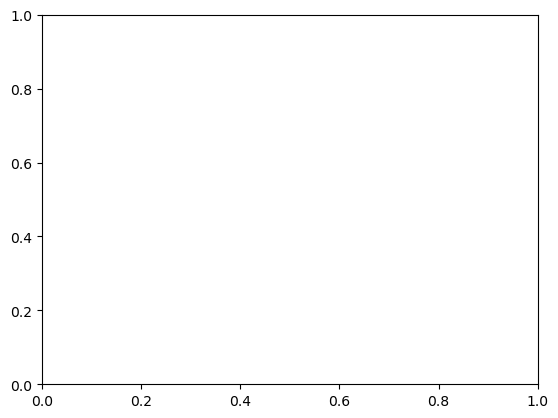

In [46]:
import numpy as np
from scipy.stats import expon
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

## Случайная величина имеет экспоненциальный закон распределения. Сгенерируйте выборку объема n = 25. 

In [47]:
lb, ub = expon.support()

In [48]:
n = 25

In [49]:
r = expon.rvs(size=n)
print(r) #нет смысла считать моду, тк числа уникальны до 8-ого знака после запятой 

[1.47275127 1.81266904 0.58394894 2.97328161 0.08022259 1.36291567
 0.06374032 0.6143189  2.48815835 4.19618157 1.65029384 0.59327059
 0.7859901  0.25096741 0.21903631 2.04078734 1.74329734 1.15649702
 1.82388406 0.79882214 0.69275174 1.23129631 0.14063426 0.06486257
 0.83176758]


## a)Определить по выборке моду, медиану, размах, оценку коэффициента ассиметрии

In [50]:
r.sort()
print(r)
print(" ")
print(r[12]) #медиана будет 13 элементом

[0.06374032 0.06486257 0.08022259 0.14063426 0.21903631 0.25096741
 0.58394894 0.59327059 0.6143189  0.69275174 0.7859901  0.79882214
 0.83176758 1.15649702 1.23129631 1.36291567 1.47275127 1.65029384
 1.74329734 1.81266904 1.82388406 2.04078734 2.48815835 2.97328161
 4.19618157]
 
0.8317675791341496


In [51]:
q2 = np.median(r)
print(q2)

0.8317675791341496


In [52]:
print((r[5] + r[6]) / 2, (r[-6] + r[-7]) /2)

0.4174581743624499 1.7779831891880753


In [53]:
q1 = np.quantile(r, 0.25)
q3 = np.quantile(r, 0.75)
print(q1, q3)

0.5839489433841992 1.7432973431071945


### Python по умолчанию считает квартили иначе, нежели мы на лекции. Диапазон индексов [0,24].

q1 = 0.25 * 24 = 6 --> q1 = r[6]

q3 = 0.75 * 24 = 18 --> q3 = r[18]

### можем задать ему метод вычисления, как на лекциях

In [54]:
q1_lec = np.quantile(r, 0.25, method="weibull")
q3_lec = np.quantile(r, 0.75, method="weibull")
print(q1_lec, q3_lec)

0.4174581743624499 1.7779831891880753


In [55]:
l = r[-1] - r[0] #размах выборки
print(l)

4.132441248256692


In [56]:
k = 3
m_3 = np.mean((r - r.mean())**k) #оценка k-ого центрального момента
m_2 = np.mean((r - r.mean())**(k-1))

gamma = m_3 / (m_2 ** (3/2))
print(gamma)

1.1811965177737274


In [57]:
y = [i/n for i in range(n)]
print(y)

[0.0, 0.04, 0.08, 0.12, 0.16, 0.2, 0.24, 0.28, 0.32, 0.36, 0.4, 0.44, 0.48, 0.52, 0.56, 0.6, 0.64, 0.68, 0.72, 0.76, 0.8, 0.84, 0.88, 0.92, 0.96]


## График эмперической функции распределения

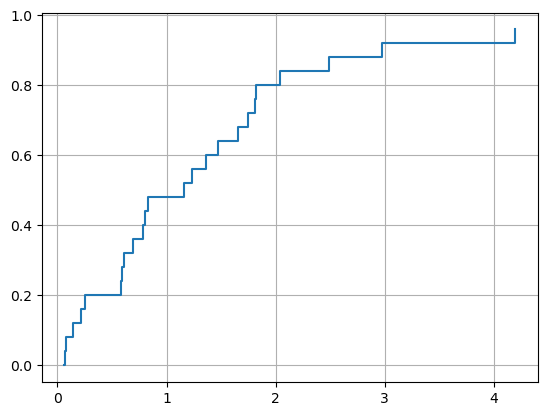

In [58]:
plt.step(r, y, where="post")
plt.grid()
plt.show()

## Гистограмма

###  Те правила построения гистограммы, которые нам давали на лекции, описывают гистограмму плотности. Высота столбца рассчитывается по правилу: h = count / n * delta, где count - количество элементов выборки, попавших в delta

### Главное свойство такой гистограммы: площадь всех её столбцов в сумме равна 1. Это позволяет напрямую сравнивать гистограмму выборки с графиком теоретической плотности вероятности.

In [59]:
k = 1 + np.log2(n)
delta = (l/k).round(1)
print(delta)

0.7


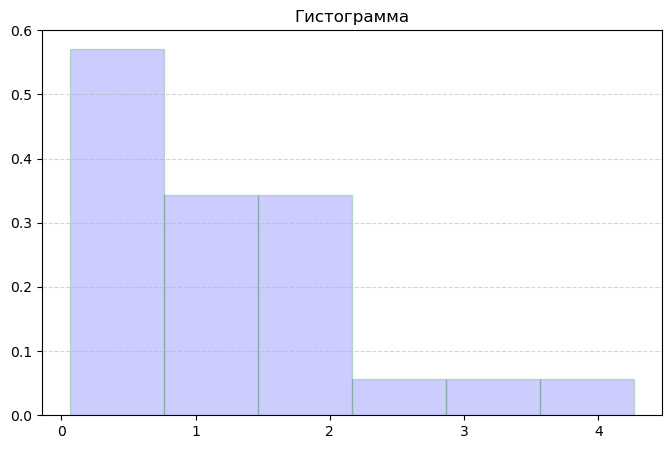

In [60]:
bins = np.arange(r.min(), r.max() + delta, delta)

plt.figure(figsize=(8, 5))
plt.hist(r, bins=bins, density=True ,edgecolor='green', color='blue', alpha=0.2)

plt.title('Гистограмма')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

## Boxplot

### boxplot -иллюстрация, которая строится по выборке по следующим правилам:
- границы ящика определяются по первому и третьему квартилю
- также отмечается второй квартиль (медиана)
- вычисляется межквартильное расстояние (IQR) по формуле = q3 - q1
- откладываются "усики" вправо и влево: q1 - 1.5 IQR; q3 + 1.5 IQR
- всё что вышло за "усики" - потенциально считаются выбросами


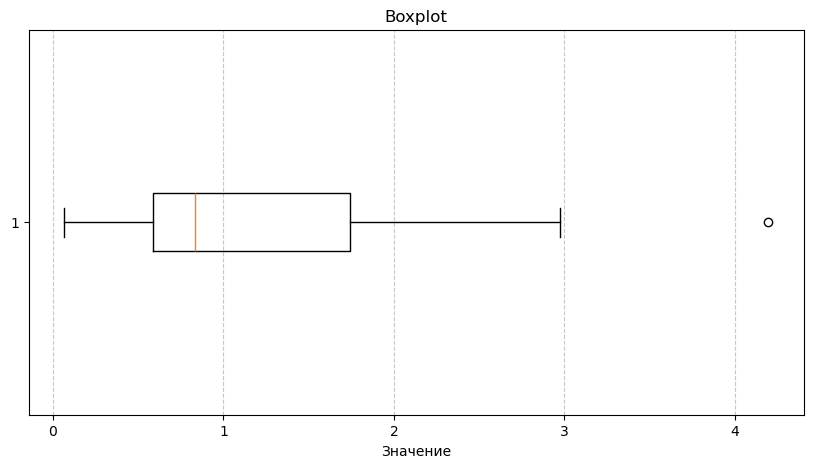

In [61]:
plt.figure(figsize=(10,5))
plt.boxplot(r, vert=False)

plt.title('Boxplot')
plt.xlabel('Значение')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

## с) Cравнить оценки плотности среднего арифметического элементов выборки, полученную с помощью ЦПТ(простейшей), с бутстраповской оценкой этой плотности.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

# Параметры
B = 10000  # количество бутстрап выборок
n = len(r) # размер моей выборки
bootstrap = np.array([np.random.choice(r, size=n, replace=True) for _ in range(B)]) 
# bootstrap_means = np.array([np.mean(i) for i in bootstrap]) 
bootstrap_means = np.mean(bootstrap, axis=1) 

Теоретическое среднее: 1.0
Теоретическая дисперсия: 1.0


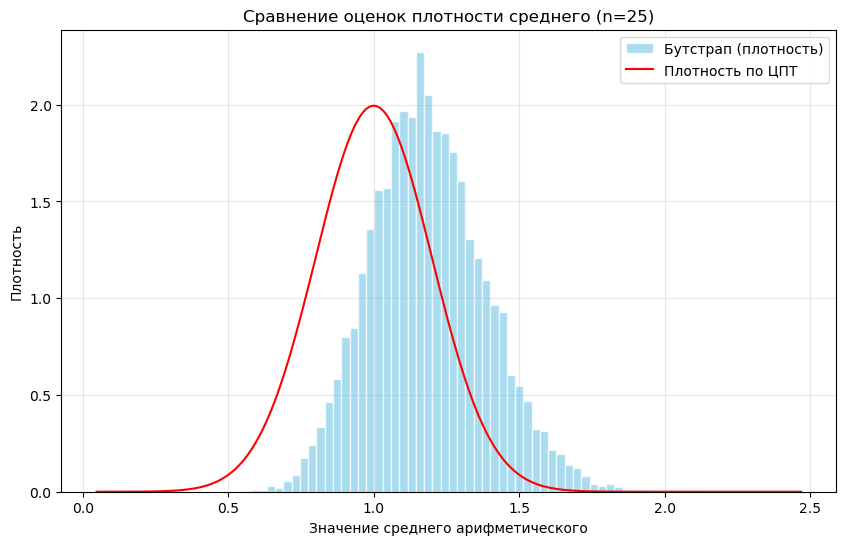

In [63]:
# 'm' - mean (мат. ожидание), 'v' - variance (дисперсия)
mu_theory, var_theory = (1.0, 1.0)

print(f"Теоретическое среднее: {mu_theory}")
print(f"Теоретическая дисперсия: {var_theory}")

mu_cpt = mu_theory # По ЦПТ среднее распределено как N(mu, sigma^2 / n)
sigma_cpt = np.sqrt(var_theory/n)

x = np.linspace(min(bootstrap_means) - 0.5, max(bootstrap_means) + 0.5, 200)

plt.figure(figsize=(10, 6))

# бутстрап
plt.hist(bootstrap_means, bins=50, density=True, color='skyblue', 
         edgecolor="white",alpha=0.7, label='Бутстрап (плотность)')

# цпт
plt.plot(x, norm.pdf(x, loc=mu_cpt, scale=sigma_cpt), 
         color="red", label="Плотность по ЦПТ") # loc - мат.ожидание, scale - стандартное отклонение

plt.title(f"Сравнение оценок плотности среднего (n={n})")
plt.xlabel("Значение среднего арифметического")
plt.ylabel("Плотность")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## d) Найти бутстраповскую оценку плотности распределения коэффициента асимметрии и оценить вероятнотсть того, что коэффициент асимметрии будет меньше 1

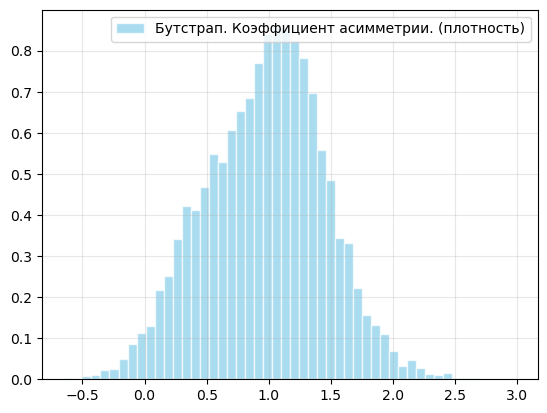

In [64]:
def solve_gamma(r):
    k = 3
    m_3 = np.mean((r - r.mean())**k) #оценка k-ого центрального момента
    m_2 = np.mean((r - r.mean())**(k-1))
    
    return m_3 / (m_2 ** (3/2))

boot_gamma = np.array([solve_gamma(i) for i in bootstrap])

plt.hist(boot_gamma, bins=50, density=True, color='skyblue', 
         edgecolor="white",alpha=0.7, label='Бутстрап. Коэффициент асимметрии. (плотность)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Вероятность, что коэффициент ассиметрии бует меньше 1

In [65]:
p = 0
for i in boot_gamma:
    if i < 1: p+=1
print(p/B)

0.5012


### Cравнить плотность распределения медианы выборки с бутстраповской оценкой этой плотности.

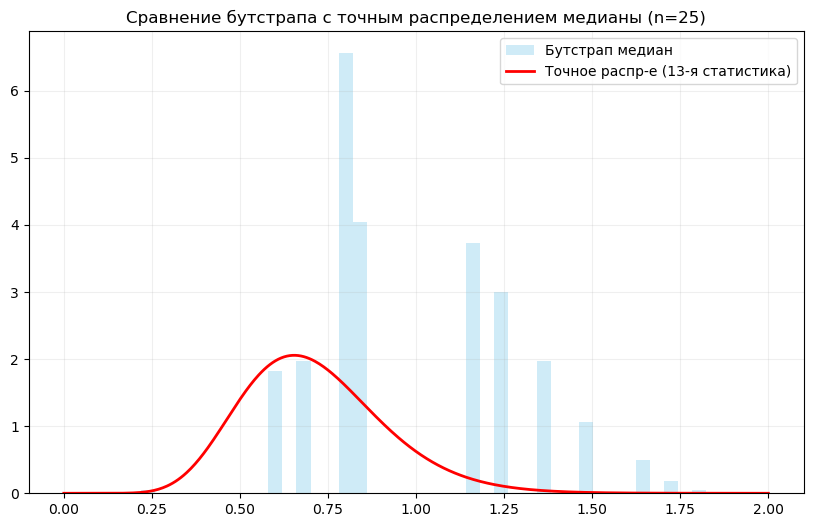

In [76]:
import scipy.special as sp

k = n // 2 + 1 # 13-я позиция

def p(x): return np.exp(-x)
def F(x): return 1 - np.exp(-x)

# Точная плотность распределения медианы (в лекции упоминалось, что так правильнее считать)
def Kappa(x):
    # n * f(x) * C(n-1, k-1) * F(x)^(k-1) * (1-F(x))^(n-k)
    return n * p(x) * sp.comb(n - 1, k - 1) * (F(x)**(k-1)) * ((1 - F(x))**(n-k))

plt.figure(figsize=(10, 6))
plt.hist(bootstrap_medians, bins=40, density=True, alpha=0.4, color='skyblue', label='Бутстрап медиан')
x_vals = np.linspace(0, 2, 500)
plt.plot(x_vals, Kappa(x_vals), 'r-', lw=2, label=f'Точное распр-е ({k}-я статистика)')

plt.title(f'Сравнение бутстрапа с точным распределением медианы (n={n})')
plt.legend()
plt.grid(alpha=0.2)
plt.show()